**Probability Mass Function**

In [1]:
import pandas as pd
import random

In [2]:
L=[]
for i in range(10000):
    L.append(random.randint(1,6))
    

In [3]:
len(L)

10000

In [4]:
pmf=(pd.Series(L).value_counts()/pd.Series(L).value_counts().sum()).sort_index()
print(pmf)


1    0.1659
2    0.1755
3    0.1676
4    0.1667
5    0.1661
6    0.1582
Name: count, dtype: float64


Cumulative Distribution functions

In [5]:
import numpy as np
cmf=np.cumsum(pmf)
print(cmf)


1    0.1659
2    0.3414
3    0.5090
4    0.6757
5    0.8418
6    1.0000
Name: count, dtype: float64


<Axes: >

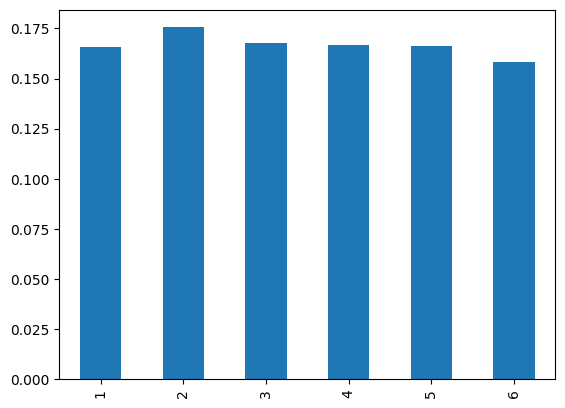

In [6]:
pmf.plot(kind='bar')

<Axes: >

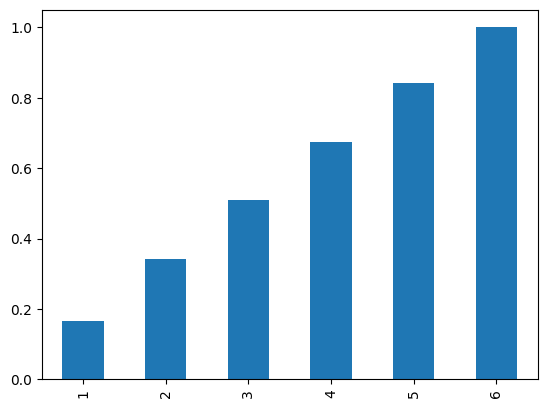

In [7]:
cmf.plot(kind='bar')

**Probability Density Function**

Parametric Density Estimation

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import normal

In [9]:
samples=normal(loc=50,scale=5,size=1000) # mean=50, std=5, number of samples=1000


In [10]:
samples.mean()

np.float64(50.039616482158515)

(array([0.00028893, 0.0017336 , 0.01155732, 0.03149369, 0.06703243,
        0.07887868, 0.05923124, 0.02687076, 0.00924585, 0.0026004 ]),
 array([31.26205097, 34.72306219, 38.1840734 , 41.64508462, 45.10609583,
        48.56710704, 52.02811826, 55.48912947, 58.95014069, 62.4111519 ,
        65.87216312]),
 <BarContainer object of 10 artists>)

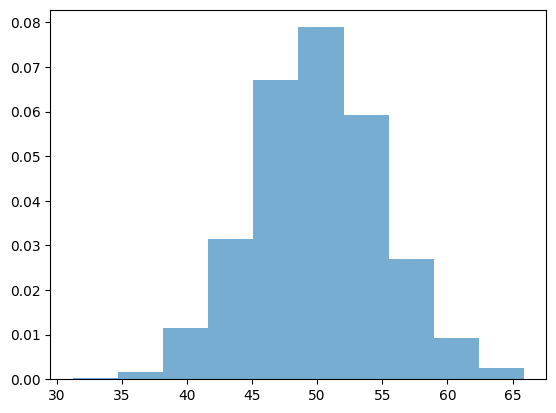

In [11]:
plt.hist(samples, bins=10, density=True, alpha=0.6, )

In [12]:
sample_mean=samples.mean()
sample_std=samples.std()

In [13]:
from scipy.stats import norm
probability_distribution=norm(loc=sample_mean, scale=sample_std)


In [14]:
probability_distribution

In [15]:
min_value=samples.min()
max_value=samples.max()
print(min_value, max_value)

31.2620509728866 65.87216311544043


In [16]:
values=np.linspace(min_value, max_value, 100)

In [17]:
probability_density=[probability_distribution.pdf(value) for value in values]

In [18]:
probability_density

[np.float64(6.084493614242869e-05),
 np.float64(7.932084583353449e-05),
 np.float64(0.00010289304182277207),
 np.float64(0.0001328068417828545),
 np.float64(0.00017056529295446675),
 np.float64(0.00021796996415255352),
 np.float64(0.00027716501693393847),
 np.float64(0.0003506839968911545),
 np.float64(0.00044149852243174264),
 np.float64(0.0005530677486980758),
 np.float64(0.0006893871536909623),
 np.float64(0.0008550348405242068),
 np.float64(0.001055213185858482),
 np.float64(0.0012957833053807294),
 np.float64(0.0015832894717735108),
 np.float64(0.0019249703313848425),
 np.float64(0.002328753548010326),
 np.float64(0.002803230383040754),
 np.float64(0.00335760672868137),
 np.float64(0.0040016272722407115),
 np.float64(0.004745469809303577),
 np.float64(0.005599607262073606),
 np.float64(0.0065746357097305),
 np.float64(0.007681067704895292),
 np.float64(0.008929091328016538),
 np.float64(0.01032829680097925),
 np.float64(0.011887374010146879),
 np.float64(0.013613785930873762),
 np

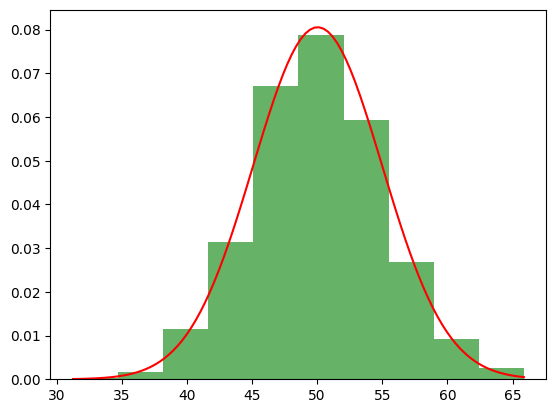

In [19]:
plt.hist(samples, bins=10, density=True, alpha=0.6, color='g')
plt.plot(values, probability_density, color='red')

<Axes: ylabel='Count'>

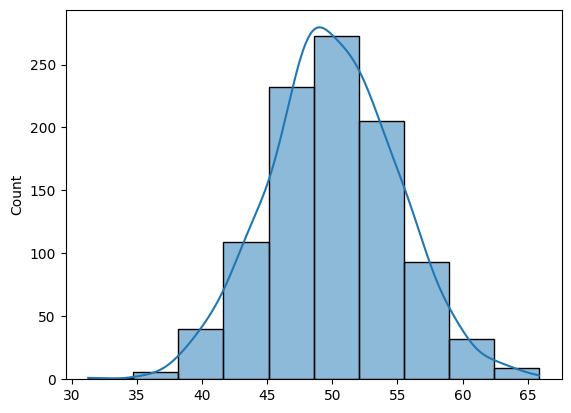

In [20]:
import seaborn as sns
sns.histplot(samples, bins=10, kde=True)

Non Parametric Density functions

Kernel Density Functions

In [21]:
sample1 = normal(loc=20, scale=5, size=300)  # loc=mean (center at 20), scale=std dev (spread 5), size=number of samples (300)
sample2 = normal(loc=40, scale=5, size=700)  # second normal group centered at 40 with same spread, 700 samples
samples = np.hstack((sample1, sample2))       # combine both arrays horizontally into one dataset

In [22]:
samples

array([20.54302795, 23.6532856 , 18.10196161, 26.8955821 , 14.79030177,
       21.83790304, 26.62522485, 19.21668884, 17.01899304, 11.72491313,
       16.78119819, 12.2539801 , 16.84941128, 25.05271524, 20.67348984,
       16.92982062, 17.98312407, 12.40419226, 17.30436481, 26.05159672,
       21.9813926 , 27.32778177, 17.0938872 , 15.39163036, 10.39015469,
       11.07724262, 19.42455426, 22.51483686, 17.53192528, 20.88169288,
       19.95461601, 22.45946012, 30.27429231, 27.76544436, 25.13842429,
       22.17740466, 28.43279904, 19.44678482, 22.32887141, 28.19371478,
       25.28533464, 22.77165989, 25.60066043, 26.14467424, 20.585604  ,
       21.43496023, 18.12762335, 15.60571712, 26.92322634, 17.32841007,
       30.3693258 , 10.37477487, 20.24540286, 25.64593857, 20.65051408,
       22.28821035, 14.52886335, 27.53689597, 18.1883715 , 24.69213154,
       16.9503687 , 24.02809311, 22.85997361, 24.66126511, 18.11469867,
       24.06422167, 23.93779743, 13.0982894 , 17.34073233, 11.80

<Axes: ylabel='Density'>

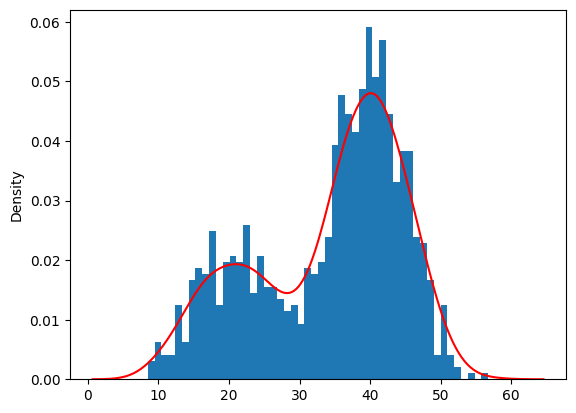

In [23]:
# plot histogram of combined samples with smooth density estimate
plt.hist(samples, bins=50, density=True)  # samples=data to plot, bins=50 creates 50 intervals, density=True normalizes the histogram
sns.kdeplot(samples, color='red')  # overlay KDE curve in red

In [24]:
from sklearn.neighbors import KernelDensity

model=KernelDensity(kernel='gaussian', bandwidth=3.0)

samples=samples.reshape(len(samples),1)
model.fit(samples)

,bandwidth,3.0
,algorithm,'auto'
,kernel,'gaussian'
,metric,'euclidean'
,atol,0
,rtol,0
,breadth_first,True
,leaf_size,40
,metric_params,None


In [25]:
min_value = samples.min()
max_value = samples.max()
values=np.linspace(min_value, max_value, 100)
values=values.reshape(len(values),1)


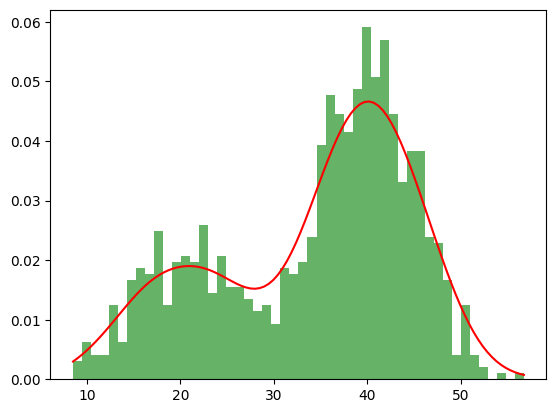

In [26]:
prob=model.score_samples(values)  # returns log density, so we need to exponentiate to get actual density
prob=np.exp(prob)  # convert log density to actual density
plt.hist(samples, bins=50, density=True, alpha=0.6, color='g')
plt.plot(values, prob, color='red')
 

In [27]:
import seaborn as sns


In [28]:
df=sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


<Axes: xlabel='sepal_length', ylabel='Density'>

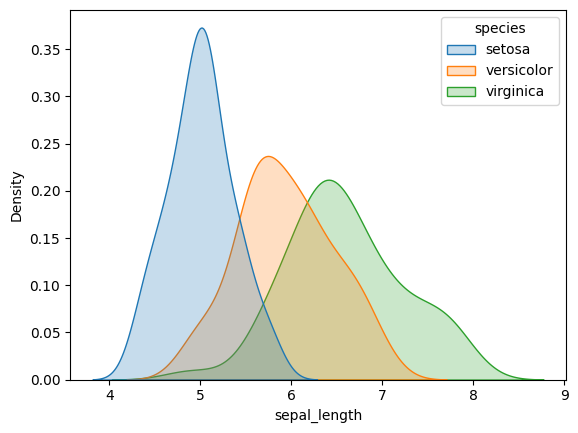

In [29]:
sns.kdeplot(data=df, x='sepal_length', hue='species', fill=True)  # data=dataframe, x=column to plot, hue=color by species, fill=shade under curve

<Axes: xlabel='petal_length', ylabel='Density'>

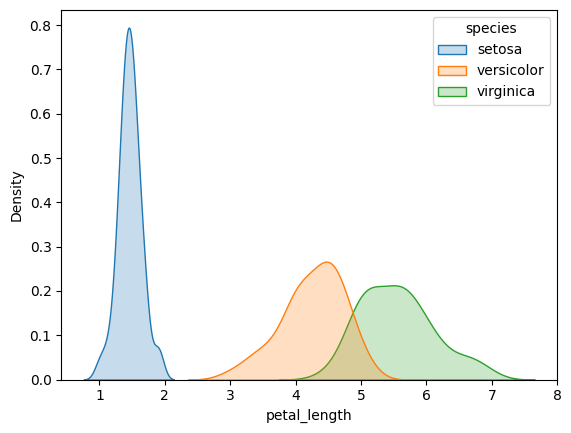

In [30]:
sns.kdeplot(data=df, x='petal_length', hue='species', fill=True)  # data=dataframe, x=column to plot, hue=color by species, fill=shade under curve

<Axes: xlabel='petal_width', ylabel='Density'>

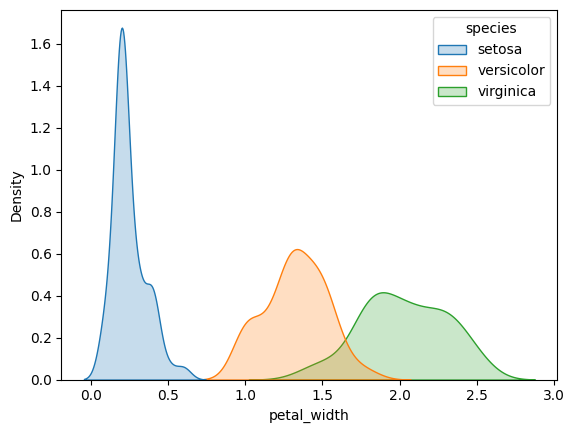

In [31]:
sns.kdeplot(data=df, x='petal_width', hue='species', fill=True)  # data=dataframe, x=column to plot, hue=color by species, fill=shade under curve

**QQ PLOT**

In [32]:
print("QQ Plot")

QQ Plot


In [33]:
import numpy as np
import pandas as pd
import seaborn as sns

In [34]:
df=sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


<Axes: xlabel='sepal_length', ylabel='Density'>

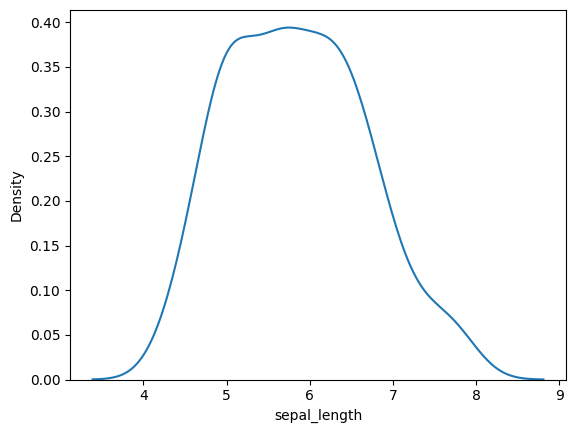

In [35]:
sns.kdeplot(df['sepal_length'])

In [36]:
temp=sorted(df['sepal_length'].tolist())

In [37]:
y_quantiles=[]

for i in range(1,101):
    y_quantiles.append(np.percentile(temp, i))

In [40]:
samples = np.random.normal(loc=0,scale=1,size=1000) # mean=0, std=1, number of samples=1000

In [42]:
x_quantiles=[]

for i in range(1,101):
    x_quantiles.append(np.percentile(samples, i))

<Axes: >

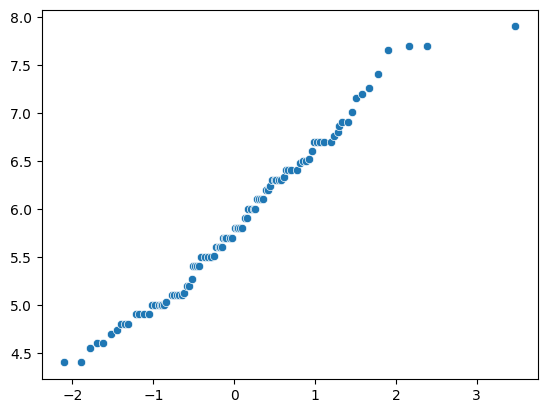

In [43]:
sns.scatterplot(x=x_quantiles, y=y_quantiles)

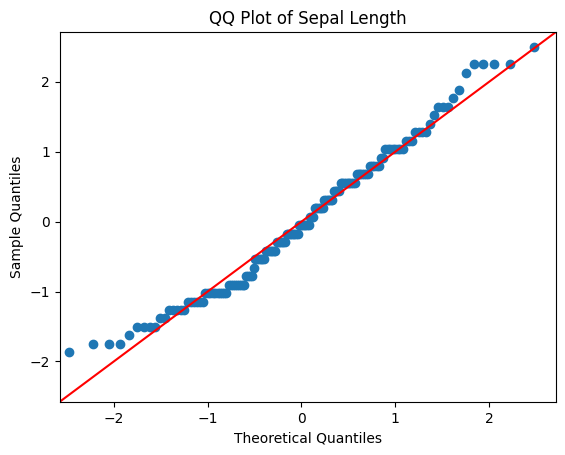

In [45]:
 # using statsmodels library for qq plot
import statsmodels.api as sm
import matplotlib.pyplot as plt

fig=sm.qqplot(df['sepal_length'], line='45', fit=True)  # line='45' adds a reference line for better visualization

plt.title('QQ Plot of Sepal Length')  # add title to the plot
plt.xlabel('Theoretical Quantiles')  # label for x-axis
plt.ylabel('Sample Quantiles')  # label for y-axis

plt.show()  # display the plot

**Uniform Distribution**

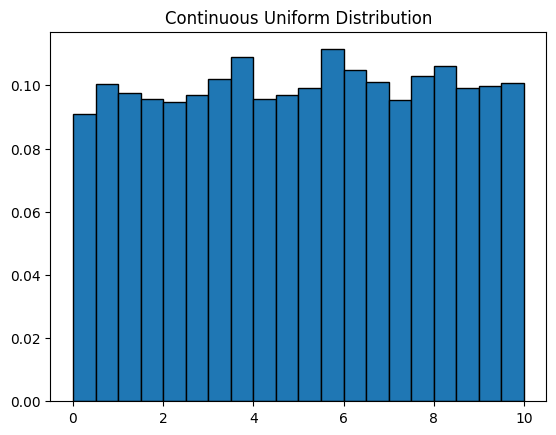

In [46]:
import numpy as np
import matplotlib.pyplot as plt

# Generate 10,000 samples between 0 and 10
samples = np.random.uniform(0, 10, 10000)

plt.hist(samples, bins=20, density=True, edgecolor='black')
plt.title("Continuous Uniform Distribution")
plt.show()

**Pareto Distribution- Log Log Plot**

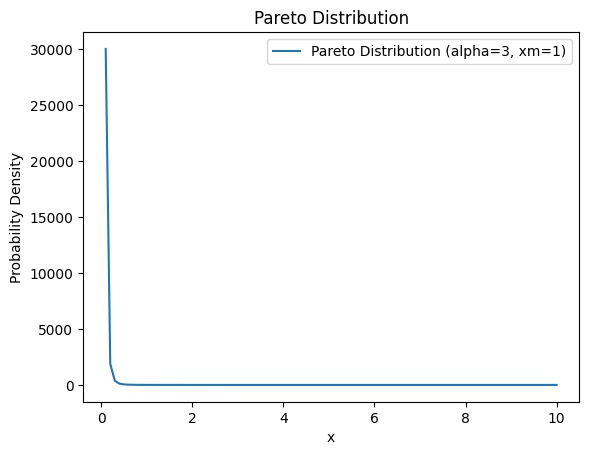

In [48]:
import numpy as np
import matplotlib.pyplot as plt

# define parameters for Pareto distribution
alpha = 3
xm = 1

# create an array of x values
x=np.linspace(0.1,10,100)


# calculate the y values for the Pareto distribution
y = (alpha * xm**alpha) / (x**(alpha + 1))

# plot the Pareto distribution
plt.plot(x, y, label='Pareto Distribution (alpha=3, xm=1)')
plt.title('Pareto Distribution')
plt.xlabel('x')
plt.ylabel('Probability Density')
plt.legend()





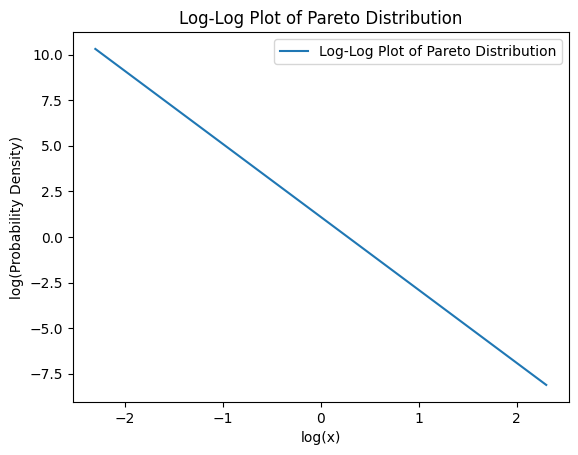

In [49]:
#create a log log plot to visualize the power-law behavior
plt.plot(np.log(x), np.log(y), label='Log-Log Plot of Pareto Distribution')
plt.title('Log-Log Plot of Pareto Distribution')
plt.xlabel('log(x)')
plt.ylabel('log(Probability Density)')
plt.legend()
plt.show()

**QQ-plot of pareto Distribution**

**Tranforms of Distribution**

In [52]:
# Non Normal Distribution data
np.random.seed(42)  # for reproducibility
x=np.random.exponential(scale=1.0, size=1000)  # scale=1.0 is the mean of the distribution
y=np.random.exponential(scale=1.0, size=1000)

df=pd.DataFrame({'x':x, 'y':y})
df.head()



,x,y
0,0.469268,0.204730
1,3.010121,0.780670
2,1.316746,2.063142
3,0.912943,1.317608
4,0.169625,1.642794


1. Log Transforms

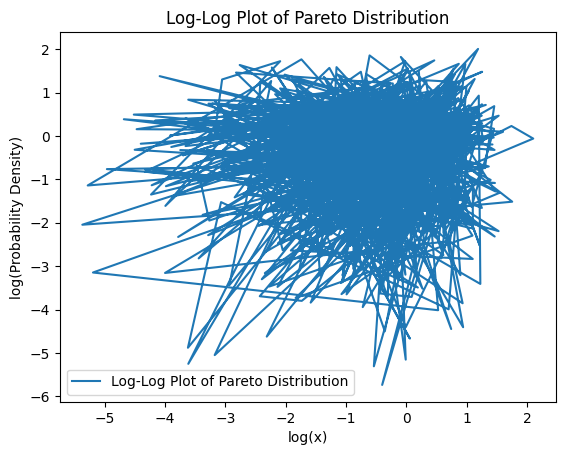

: 

In [ ]:
# apply log transformation to the data
log_x = np.log(x)
log_y = np.log(y)

# plot the log-log plot
plt.plot(log_x, log_y, label='Log-Log Plot of Pareto Distribution')
plt.title('Log-Log Plot of Pareto Distribution')
plt.xlabel('log(x)')
plt.ylabel('log(Probability Density)')
plt.legend()

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

def apply_transform(transform):
    x=df.iloc[:1,3]
    y=df.iloc[:0]

    trf=ColumnTransformer([('log',FunctionTransformer(transform),['Fare'])],remainder='passthrough')
    x_trf=trf.fit_transform(x)  
